In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
source("InstallAndLoadScripts/loadlibraries.R")

In [3]:
loadISLR2Libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘gridExtra’


The following object is mas

In [4]:
names(Smarket)

[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"

In [5]:
dim(Smarket)

[1] 1250    9

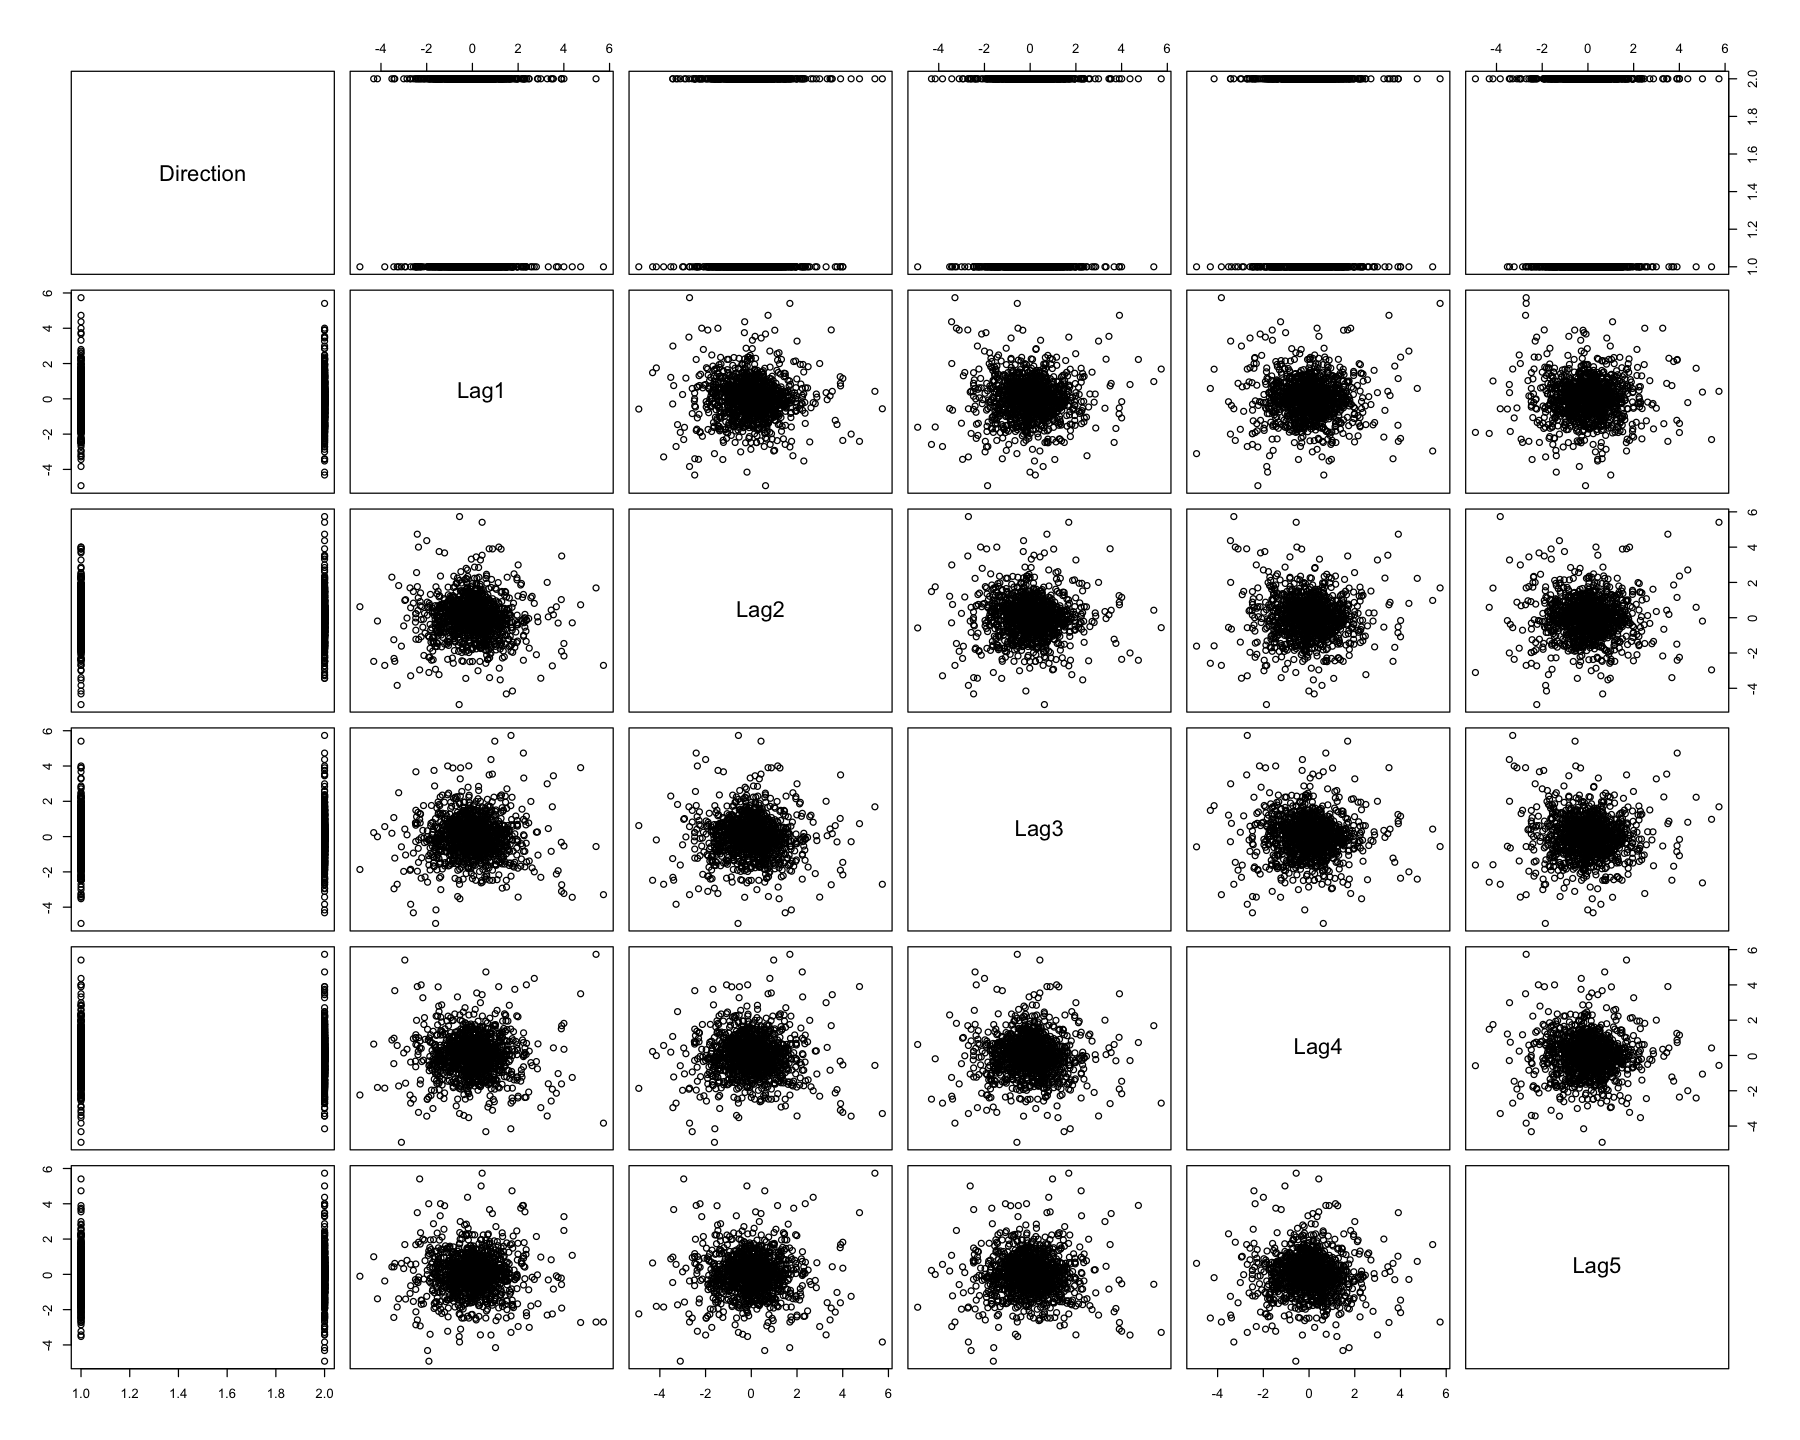

In [6]:
options(repr.plot.width = 15, repr.plot.height = 12)
pairs(Smarket[c("Direction", "Lag1", "Lag2", "Lag3", "Lag4", "Lag5")])

In [7]:
cor(Smarket[, -9])

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.00000000,0.029699649,0.030596422,0.033194581,0.035688718,0.029787995,0.53900647,0.030095229
Lag1,0.02969965,1.000000000,-0.026294328,-0.010803402,-0.002985911,-0.005674606,0.04090991,-0.026155045
Lag2,0.03059642,-0.026294328,1.000000000,-0.025896670,-0.010853533,-0.003557949,-0.04338321,-0.010250033
Lag3,0.03319458,-0.010803402,-0.025896670,1.000000000,-0.024051036,-0.018808338,-0.04182369,-0.002447647
Lag4,0.03568872,-0.002985911,-0.010853533,-0.024051036,1.000000000,-0.027083641,-0.04841425,-0.006899527
Lag5,0.02978799,-0.005674606,-0.003557949,-0.018808338,-0.027083641,1.000000000,-0.02200231,-0.034860083
Volume,0.53900647,0.040909908,-0.043383215,-0.041823686,-0.048414246,-0.022002315,1.00000000,0.014591823
Today,0.03009523,-0.026155045,-0.010250033,-0.002447647,-0.006899527,-0.034860083,0.01459182,1.000000000


In [8]:
attach(Smarket)

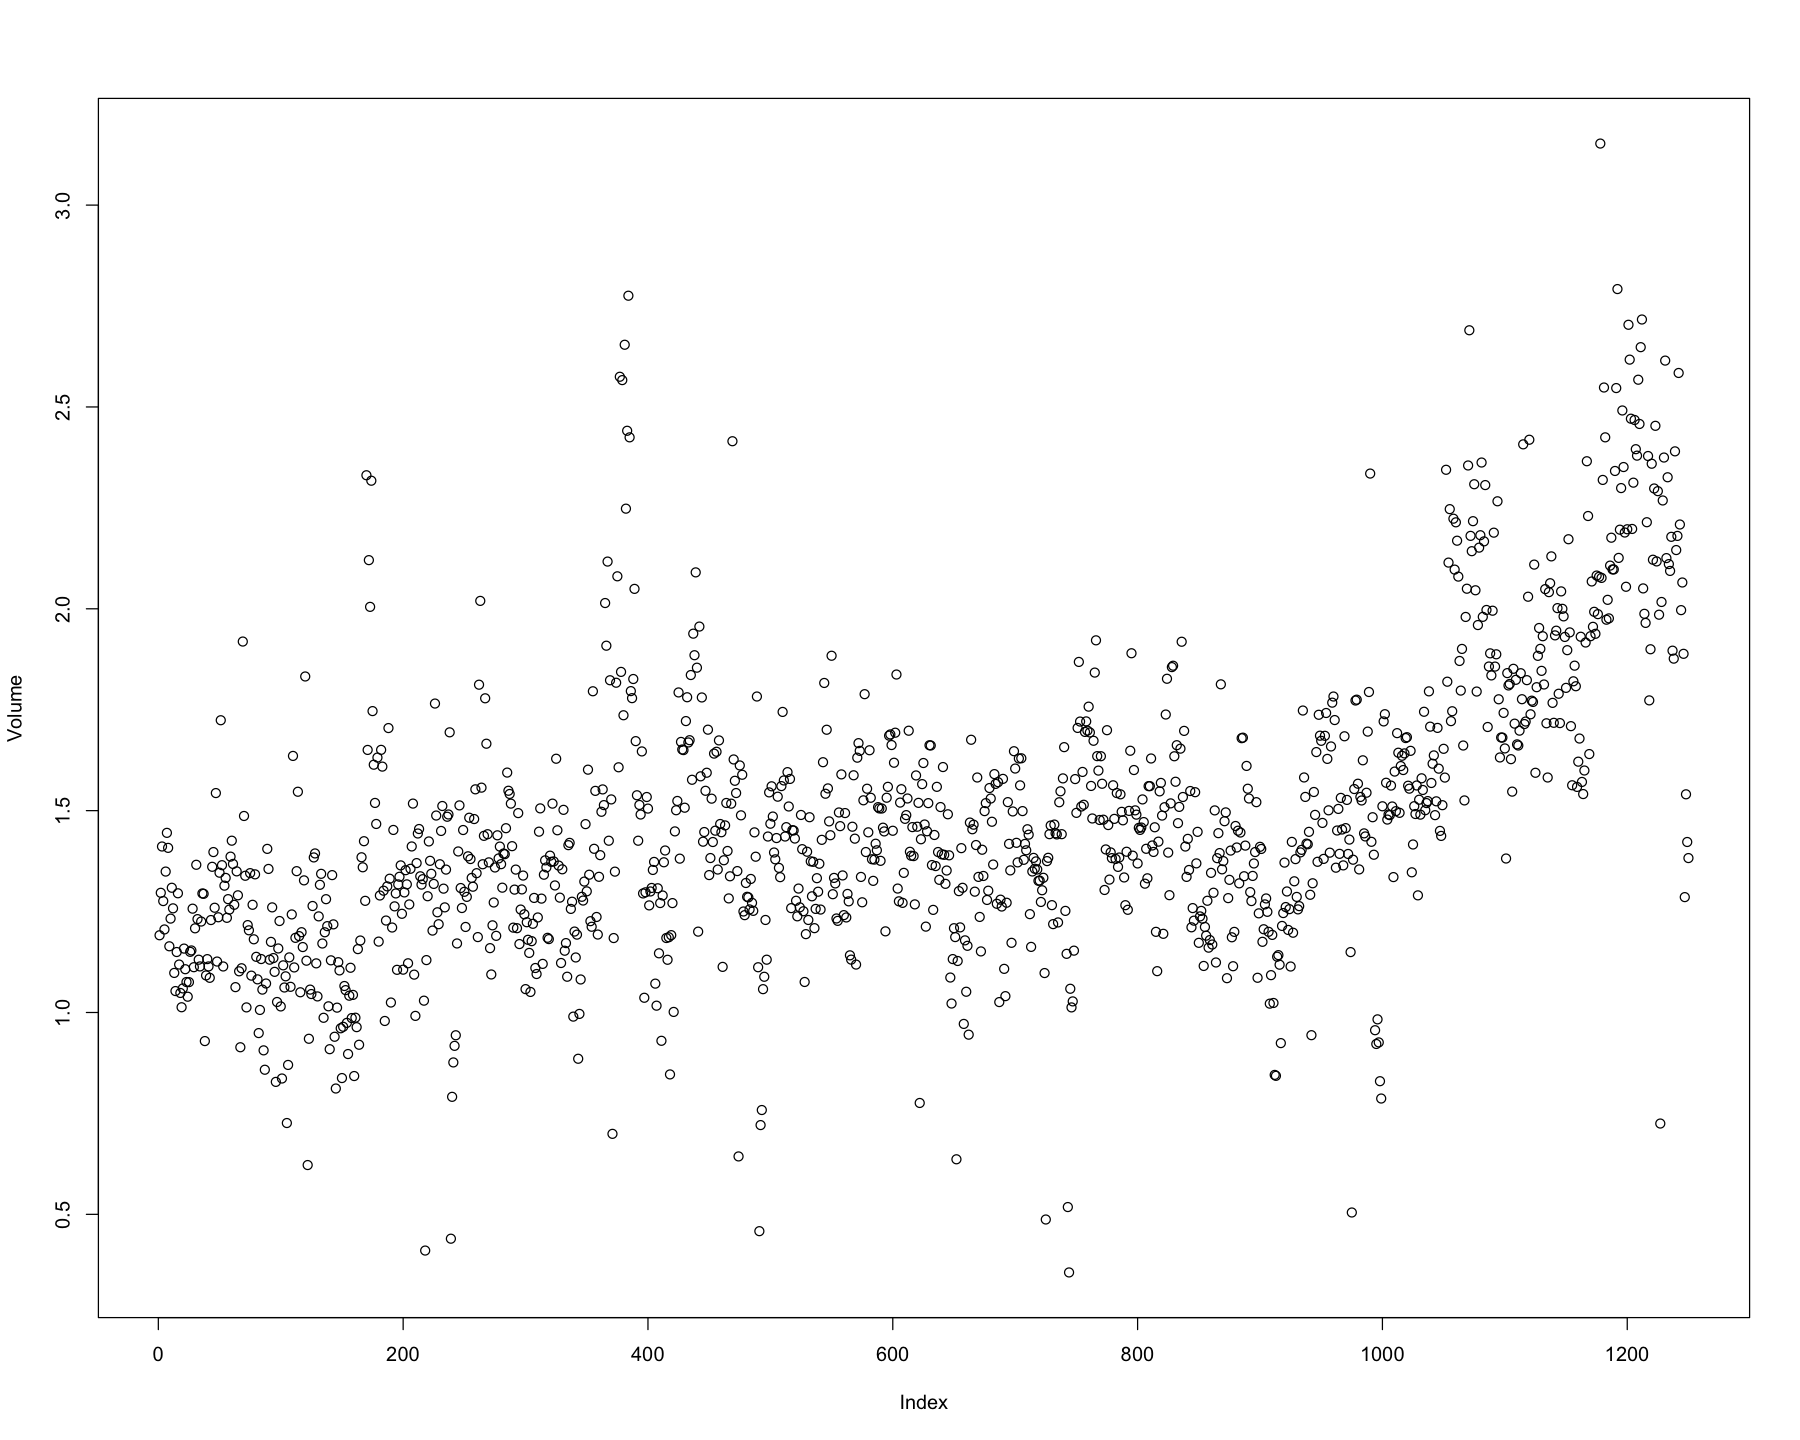

In [9]:
plot(Volume)

In [10]:
glm01 = glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume, data=Smarket, family = binomial)

In [11]:
summary(glm01)


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Smarket)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.126000   0.240736  -0.523    0.601
Lag1        -0.073074   0.050167  -1.457    0.145
Lag2        -0.042301   0.050086  -0.845    0.398
Lag3         0.011085   0.049939   0.222    0.824
Lag4         0.009359   0.049974   0.187    0.851
Lag5         0.010313   0.049511   0.208    0.835
Volume       0.135441   0.158360   0.855    0.392

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1731.2  on 1249  degrees of freedom
Residual deviance: 1727.6  on 1243  degrees of freedom
AIC: 1741.6

Number of Fisher Scoring iterations: 3


In [12]:
glm.probs = predict(glm01, type="response")

In [13]:
print(glm.probs[1:10])

        1         2         3         4         5         6         7         8 
0.5070841 0.4814679 0.4811388 0.5152224 0.5107812 0.5069565 0.4926509 0.5092292 
        9        10 
0.5176135 0.4888378 


In [14]:
contrasts(Direction)

,Up
Down,0
Up,1


In [1]:
glm.pred = rep("Down", 1250)
glm.pred[glm.probs > .5] = "Up"
table(glm.pred, Direction)

ERROR: Error: object 'glm.probs' not found


In [91]:
(507+145)/1250

[1] 0.5216

In [18]:
mean(glm.pred == Direction)

[1] 0.5216

## Select training and validation observations

In [19]:
train = (Year < 2005)

In [20]:
Smarket.2005 = Smarket[!train,]

In [21]:
dim(Smarket.2005)

[1] 252   9

In [22]:
Direction.2005 = Direction[!train]

In [23]:
glm02 = glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume, 
            data = Smarket, family = binomial, subset = train)

In [24]:
summary(glm02)


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Smarket, subset = train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept)  0.191213   0.333690   0.573    0.567
Lag1        -0.054178   0.051785  -1.046    0.295
Lag2        -0.045805   0.051797  -0.884    0.377
Lag3         0.007200   0.051644   0.139    0.889
Lag4         0.006441   0.051706   0.125    0.901
Lag5        -0.004223   0.051138  -0.083    0.934
Volume      -0.116257   0.239618  -0.485    0.628

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1383.3  on 997  degrees of freedom
Residual deviance: 1381.1  on 991  degrees of freedom
AIC: 1395.1

Number of Fisher Scoring iterations: 3


## Predict 2005 values based on model trained with <2005 data

In [25]:
glm02.probs = predict(glm02, Smarket.2005, type="response")

In [26]:
glm02.pred = rep("Down", 252)

In [27]:
glm02.pred[glm02.probs > .5] = "Up"

In [28]:
table(glm02.pred, Direction.2005)

          Direction.2005
glm02.pred Down Up
      Down   77 97
      Up     34 44

In [29]:
mean(glm02.pred == Direction.2005)

[1] 0.4801587

## Use only more significant predictors

In [30]:
glm03 = glm(Direction ~ Lag1 + Lag2, data=Smarket, family=binomial, 
            subset=train)

In [31]:
summary(glm03)


Call:
glm(formula = Direction ~ Lag1 + Lag2, family = binomial, data = Smarket, 
    subset = train)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  0.03222    0.06338   0.508    0.611
Lag1        -0.05562    0.05171  -1.076    0.282
Lag2        -0.04449    0.05166  -0.861    0.389

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1383.3  on 997  degrees of freedom
Residual deviance: 1381.4  on 995  degrees of freedom
AIC: 1387.4

Number of Fisher Scoring iterations: 3


In [32]:
glm03.probs = predict(glm03, Smarket.2005, type="response")

In [33]:
glm03.pred = rep("Down", 252)

In [34]:
glm03.pred[glm03.probs > .5] = "Up"

In [35]:
table(glm03.pred, Direction.2005)

          Direction.2005
glm03.pred Down  Up
      Down   35  35
      Up     76 106

In [36]:
mean(glm03.pred == Direction.2005)

[1] 0.5595238

## Linear Discriminant Analysis

In [96]:
lda01.fit = lda(Direction ~ Lag1 + Lag2, data=Smarket, subset=train)

In [102]:
lda01.fit

Call:
lda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)

Prior probabilities of groups:
    Down       Up 
0.491984 0.508016 

Group means:
            Lag1        Lag2
Down  0.04279022  0.03389409
Up   -0.03954635 -0.03132544

Coefficients of linear discriminants:
            LD1
Lag1 -0.6420190
Lag2 -0.5135293

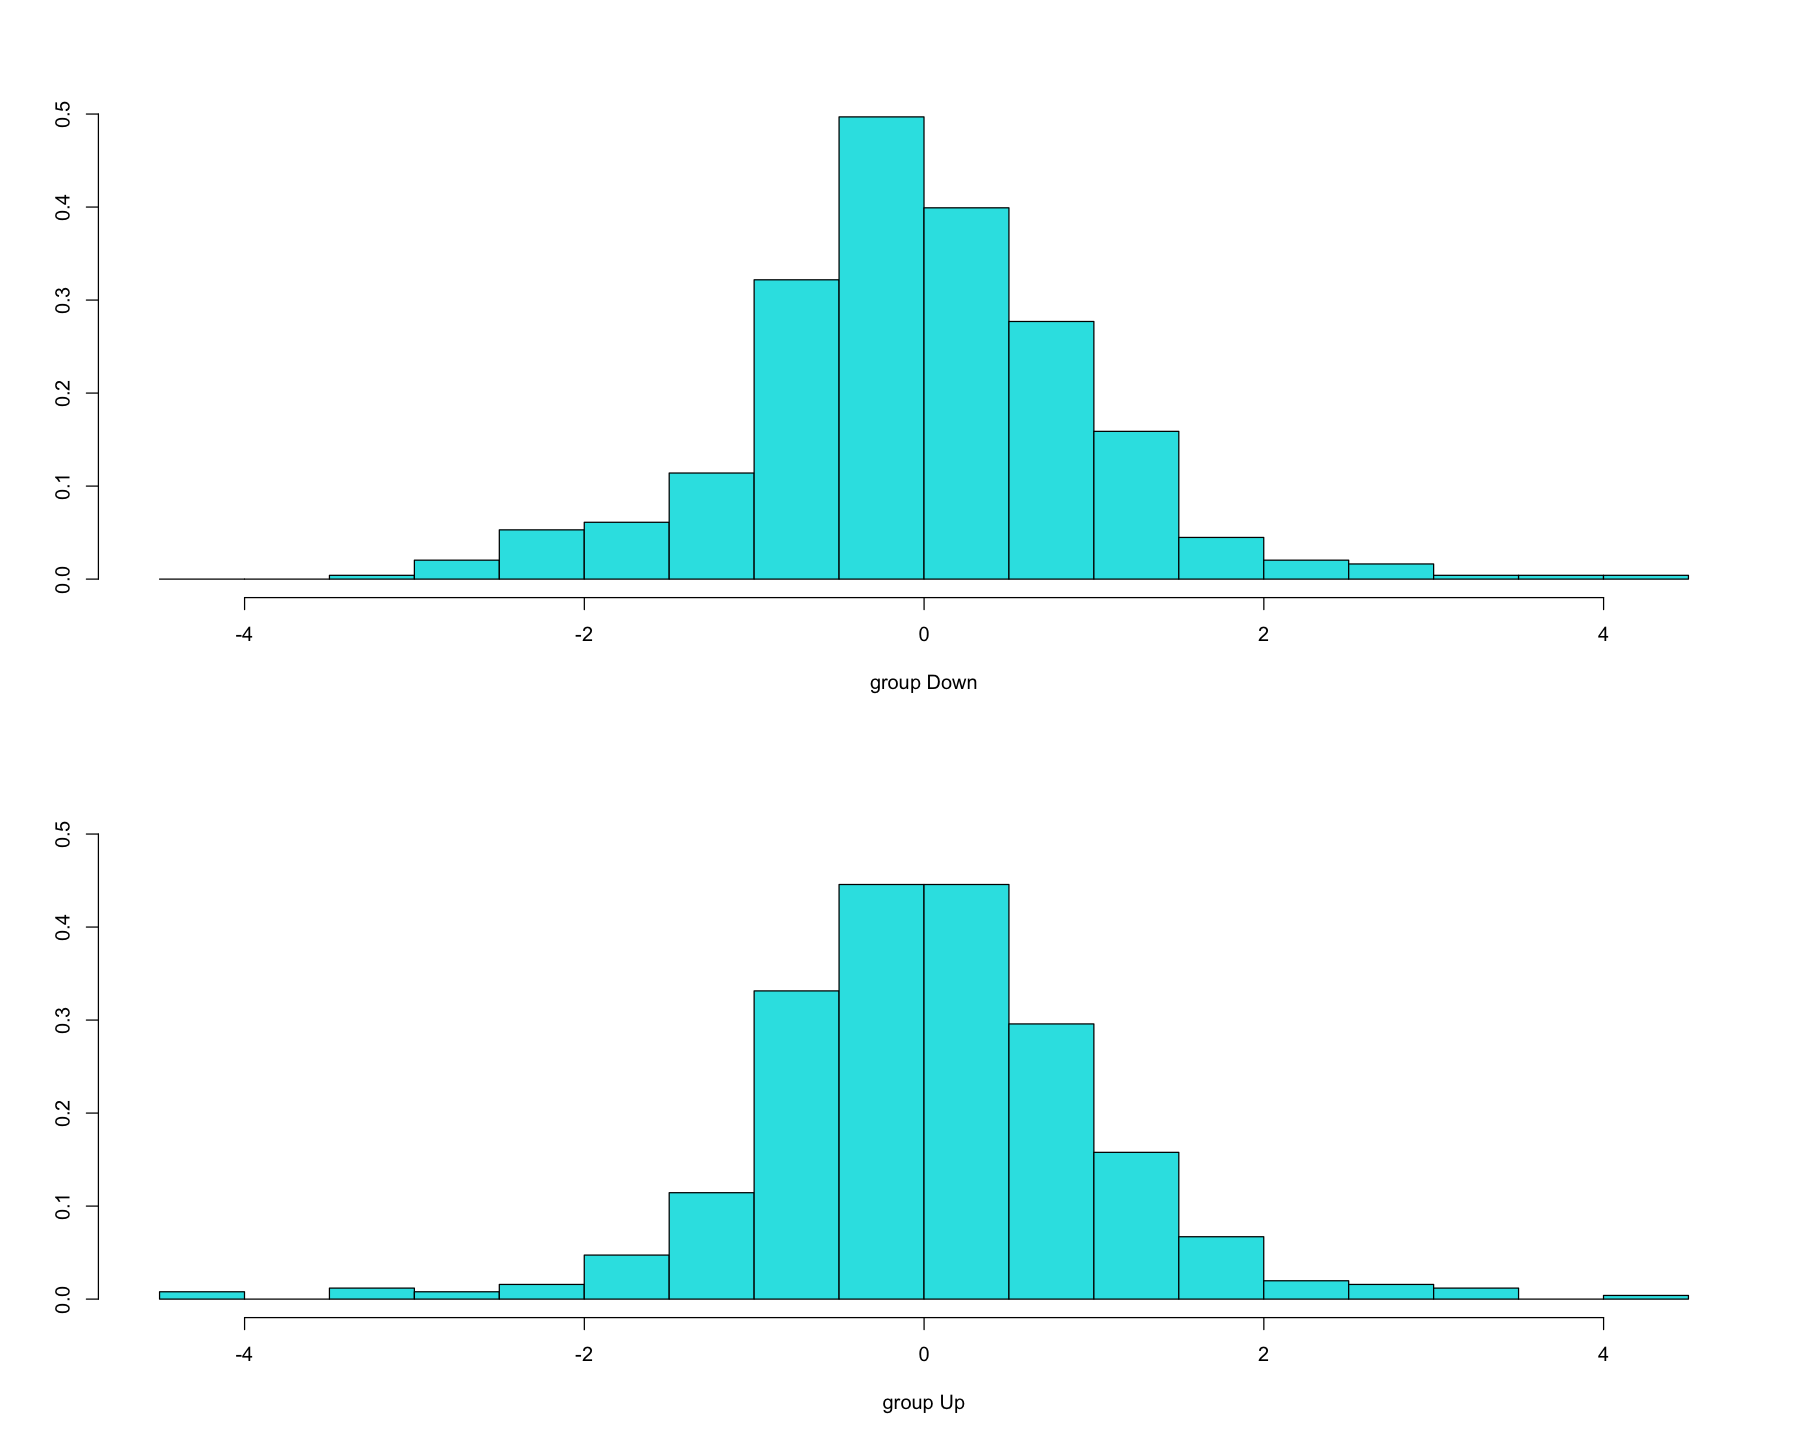

In [103]:
plot(lda01.fit)

In [111]:
lda01.pred = predict(lda01.fit, Smarket.2005)

In [112]:
names(lda01.pred)

[1] "class"     "posterior" "x"

In [113]:
lda01.class = lda01.pred$class

In [114]:
table(lda01.class, Direction.2005)

           Direction.2005
lda01.class Down  Up
       Down   35  35
       Up     76 106

In [120]:
length(Direction.2005)

[1] 252

In [121]:
141/252

[1] 0.5595238

In [115]:
mean(lda01.class == Direction.2005)

[1] 0.5595238

In [116]:
sum(lda01.pred$posterior[, 1] > .5)

[1] 70

In [117]:
sum(lda01.pred$posterior[, 1] < .5)

[1] 182

## Quadratic Discriminant Analysis

In [122]:
qda01.fit = qda(Direction ~ Lag1 + Lag2, data=Smarket, subset=train)

In [124]:
qda01.fit

Call:
qda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)

Prior probabilities of groups:
    Down       Up 
0.491984 0.508016 

Group means:
            Lag1        Lag2
Down  0.04279022  0.03389409
Up   -0.03954635 -0.03132544

In [128]:
names(qda01.fit)

[1] "prior"   "counts"  "means"   "scaling" "ldet"    "lev"     "N"      
 [8] "call"    "terms"   "xlevels"

In [131]:
qda.class <- predict(qda01.fit, Smarket.2005)$class

In [133]:
table(qda.class, Direction.2005)

         Direction.2005
qda.class Down  Up
     Down   30  20
     Up     81 121

In [134]:
151/251

[1] 0.6015936

## Naive Bayes

In [ ]:
library(e1071)

In [135]:
nb.fit = naiveBayes(Direction ~ Lag1 + Lag2, data=Smarket, subset=train)

In [136]:
nb.fit


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
    Down       Up 
0.491984 0.508016 

Conditional probabilities:
      Lag1
Y             [,1]     [,2]
  Down  0.04279022 1.227446
  Up   -0.03954635 1.231668

      Lag2
Y             [,1]     [,2]
  Down  0.03389409 1.239191
  Up   -0.03132544 1.220765


In [137]:
names(nb.fit)

[1] "apriori"   "tables"    "levels"    "isnumeric" "call"

In [138]:
mean(Lag1[train][Direction[train] == "Down"])

[1] 0.04279022

In [139]:
sd(Lag1[train][Direction[train] == "Down"])

[1] 1.227446

## KNN

In [104]:
library(class)

In [105]:
train.X = cbind(Lag1, Lag2)[train,]

In [106]:
test.X = cbind(Lag1, Lag2)[!train,]

In [107]:
train.Direction = Direction[train]

In [108]:
set.seed(3)

In [109]:
knn01.pred = knn(train.X, test.X, train.Direction, k=1)

In [46]:
table(knn01.pred, Direction.2005)

          Direction.2005
knn01.pred Down Up
      Down   43 58
      Up     68 83

In [47]:
knn03.pred = knn(train.X, test.X, train.Direction, k=3)
table(knn03.pred, Direction.2005)

          Direction.2005
knn03.pred Down Up
      Down   48 56
      Up     63 85

In [48]:
mean(knn03.pred == Direction.2005)

[1] 0.5277778

In [49]:
dim(Caravan)

[1] 5822   86

In [50]:
attach(Caravan)

In [51]:
summary(Purchase)

No  Yes 
5474  348

In [52]:
348/(5474+348)

[1] 0.05977327

In [53]:
standardized.X = scale(Caravan[, -86])

In [54]:
var(Caravan[,1])

[1] 165.0378

In [55]:
var(Caravan[,2])

[1] 0.1647078

In [56]:
var(standardized.X[,1])

[1] 1

In [57]:
var(standardized.X[,2])

[1] 1

In [58]:
test = 1:1000

In [59]:
train.X = standardized.X[-test,]

In [60]:
test.X = standardized.X[test,]

In [61]:
train.Y = Purchase[-test]

In [62]:
test.Y = Purchase[test]

In [63]:
set.seed(1)

In [64]:
knn04.pred = knn(train.X, test.X, train.Y, k=1)

In [65]:
mean(test.Y != knn04.pred)

[1] 0.115

In [66]:
mean(test.Y != "No")

[1] 0.059

In [67]:
table(knn04.pred, test.Y)

          test.Y
knn04.pred  No Yes
       No  875  49
       Yes  66  10

In [68]:
table(knn04.pred, test.Y)

          test.Y
knn04.pred  No Yes
       No  875  49
       Yes  66  10

In [69]:
9/(9+68)

[1] 0.1168831

In [70]:
knn05.pred = knn(train.X, test.X, train.Y, k=3)

In [71]:
5/26

[1] 0.1923077

In [72]:
knn06.pred = knn(train.X, test.X, train.Y, k=5)

In [73]:
table(knn06.pred, test.Y)

          test.Y
knn06.pred  No Yes
       No  930  55
       Yes  11   4

In [74]:
4/15

[1] 0.2666667

In [75]:
glm04 = glm(Purchase ~ ., data=Caravan, family=binomial,
            subset=-test)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


In [76]:
glm04.probs = predict(glm04, Caravan[test,])

In [77]:
glm04.pred = rep("No", 1000)

In [78]:
glm04.pred[glm04.probs > .5] = "Yes"

In [79]:
table(glm04.pred, test.Y)

          test.Y
glm04.pred  No Yes
       No  937  59
       Yes   4   0

In [80]:
glm04.pred = rep("No", 1000)

In [81]:
glm04.pred[glm04.probs > .25] = "Yes"

In [82]:
table(glm04.pred, test.Y)

          test.Y
glm04.pred  No Yes
       No  935  59
       Yes   6   0

In [83]:
attach(Bikeshare)

In [84]:
dim(Bikeshare)

[1] 8645   15

In [85]:
names(Bikeshare)

[1] "season"     "mnth"       "day"        "hr"         "holiday"   
 [6] "weekday"    "workingday" "weathersit" "temp"       "atemp"     
[11] "hum"        "windspeed"  "casual"     "registered" "bikers"

In [86]:
lm01 = lm(bikers ~ mnth + hr + workingday + temp +
          weathersit, data=Bikeshare)

In [87]:
summary(lm01)


Call:
lm(formula = bikers ~ mnth + hr + workingday + temp + weathersit, 
    data = Bikeshare)

Residuals:
    Min      1Q  Median      3Q     Max 
-299.00  -45.70   -6.23   41.08  425.29 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)                -68.632      5.307 -12.932  < 2e-16 ***
mnthFeb                      6.845      4.287   1.597 0.110398    
mnthMarch                   16.551      4.301   3.848 0.000120 ***
mnthApril                   41.425      4.972   8.331  < 2e-16 ***
mnthMay                     72.557      5.641  12.862  < 2e-16 ***
mnthJune                    67.819      6.544  10.364  < 2e-16 ***
mnthJuly                    45.324      7.081   6.401 1.63e-10 ***
mnthAug                     53.243      6.640   8.019 1.21e-15 ***
mnthSept                    66.678      5.925  11.254  < 2e-16 ***
mnthOct                     75.834      4.950  15.319  < 2e-16 ***
mnthNov                     60.310      4.610  13.083  < 2

## Poisson regression